# N2 · 离散 vs 连续动作头

> 配套 11.2-L3 · 同一个 backbone, 换两种动作头 (离散 9 类 token / 连续 2D 回归)。
> 对比成功率 (都高) 和**动作平滑度** (连续远胜)。体会离散的「跳」和连续的「滑」, 及连续怕多峰。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import mini_vla as vla
import toy_env as env, action_serialize as ser   # M11.1 共享 (mini_vla 已加进 path)
import numpy as np, torch

## 1. 训练两种动作头 (离散 / 连续)

In [2]:
torch.manual_seed(0)
S, A = env.make_demos(n=400, seed=0)
results = {}
for head in ["discrete", "continuous"]:
    m = vla.build_mini_vla(head=head)
    losses = vla.train_vla(m, S, A, epochs=400)
    sr = env.eval_policy(vla.make_policy(m), n_episodes=200)
    sm = vla.action_smoothness(m)
    results[head] = dict(model=m, sr=sr, sm=sm)
    print(f"{head:11} 头: 成功率 {sr:.2f}, 动作平滑度 {sm:.3f} (越小越平滑)")

discrete    头: 成功率 1.00, 动作平滑度 0.351 (越小越平滑)


continuous  头: 成功率 1.00, 动作平滑度 0.085 (越小越平滑)


## 2. 可视化: 离散「跳」 vs 连续「滑」

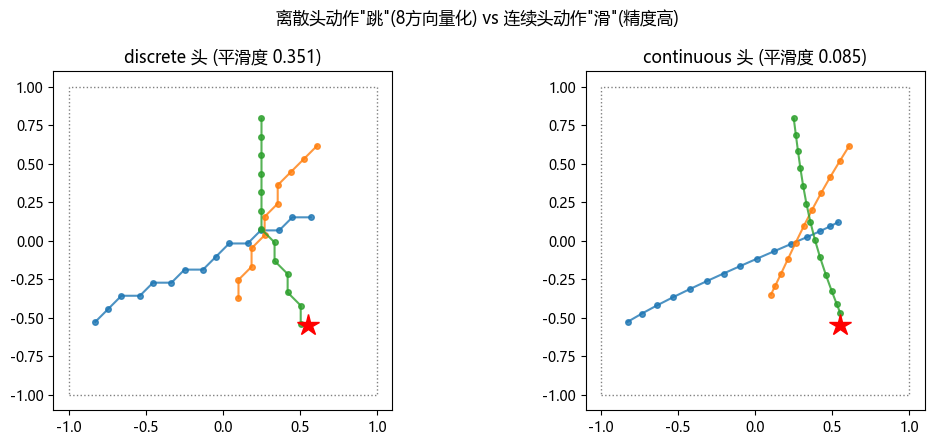

平滑度: 离散 0.351 vs 连续 0.085 (连续平滑 4.1×)


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, head in zip(axes, ["discrete", "continuous"]):
    pol = vla.make_policy(results[head]["model"])
    for seed in [3,5,7]:
        ok, steps, traj = env.rollout(pol, seed=seed, record=True); traj=np.array(traj)
        ax.plot(traj[:,0], traj[:,1], '-o', ms=4, alpha=0.8)
    ax.plot(traj[0,2], traj[0,3], 'r*', ms=16)
    ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='gray'))
    ax.set_title(f'{head} 头 (平滑度 {results[head]["sm"]:.3f})'); ax.set_aspect('equal')
plt.suptitle('离散头动作"跳"(8方向量化) vs 连续头动作"滑"(精度高)'); plt.tight_layout(); plt.show()
print(f'平滑度: 离散 {results["discrete"]["sm"]:.3f} vs 连续 {results["continuous"]["sm"]:.3f} '
      f'(连续平滑 {results["discrete"]["sm"]/results["continuous"]["sm"]:.1f}×)')

## 3. 连续头的阿喀琉斯之踵: 多峰取平均

In [4]:
print('''离散 vs 连续的代价 (L3):
  离散 token:  ✓ 复用 LLM + 天然多峰   ✗ 离散化损失 (动作"跳", 精度粗)
  连续回归:    ✓ 精度高 + 动作平滑     ✗ 怕多峰 (MSE 取平均)

多峰问题 (连续回归的死穴):
  若同一状态有两个合理动作 (绕障碍可左可右),
  MSE 回归会学成"取平均" = 中间方向 = 直接撞上去 ✗
  → 这就是为什么要扩散/flow 动作头 (M11.3): 既连续又多峰, 两全。''')

离散 vs 连续的代价 (L3):
  离散 token:  ✓ 复用 LLM + 天然多峰   ✗ 离散化损失 (动作"跳", 精度粗)
  连续回归:    ✓ 精度高 + 动作平滑     ✗ 怕多峰 (MSE 取平均)

多峰问题 (连续回归的死穴):
  若同一状态有两个合理动作 (绕障碍可左可右),
  MSE 回归会学成"取平均" = 中间方向 = 直接撞上去 ✗
  → 这就是为什么要扩散/flow 动作头 (M11.3): 既连续又多峰, 两全。


## 4. 反思 (11.2 收口)

你对比了离散 vs 连续动作头, 看清各自代价。带走:
- **离散**: 复用 LLM + 天然多峰, 但离散化损失 (动作跳, 精度粗) — OpenVLA 路线。
- **连续**: 精度高 + 平滑 (实测平滑 4×), 但怕多峰 (MSE 取平均 → 撞)。
- 两者各缺一块 → **扩散/flow 动作头** (M11.3) 补齐: 连续 + 多峰 + 平滑。

> **M11.2 收口**: VLA = backbone (M10 VLM) + 动作头; 动作头是核心自由度; 离散/连续各有代价。
> **交棒 M11.3「action-heads-diffusion-policy」**: 动作头巅峰 —— 用你 M13 的扩散做动作头, 解决多峰+连续+平滑 (π 的核心)。下一专题 `action-heads-diffusion-policy`。